## MEAN & MEDIAN IMPUTATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### import sklearn.libraries

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

### Import Dataset

In [3]:
df = pd.read_csv('titanic_toy (1).csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [5]:
df.sample(10)

,Age,Fare,Family,Survived
761,41.0,7.1250,0,0
52,49.0,76.7292,1,1
449,52.0,30.5000,0,1
570,62.0,10.5000,0,1
91,20.0,7.8542,0,0
188,40.0,15.5000,2,0
453,49.0,89.1042,1,1
552,NaN,7.8292,0,0
214,NaN,7.7500,1,0
368,NaN,7.7500,0,1


### Perform Train Test Split

In [6]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [8]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [9]:
x_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

### Calculate Mean and Median (Age | Fare)

In [10]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

### Create new Column & immute missing value

In [11]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)

In [12]:
x_train.sample(8)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
324,NaN,69.5500,10,28.75,29.785904,69.5500,69.550000
518,36.0,NaN,1,36.00,36.000000,14.4583,32.617597
97,23.0,63.3583,1,23.00,23.000000,63.3583,63.358300
191,19.0,13.0000,0,19.00,19.000000,13.0000,13.000000
667,NaN,7.7750,0,28.75,29.785904,7.7750,7.775000
649,23.0,NaN,0,23.00,23.000000,14.4583,32.617597
320,22.0,7.2500,0,22.00,22.000000,7.2500,7.250000
609,40.0,153.4625,0,40.00,40.000000,153.4625,153.462500


### Review Variance

In [13]:
print('Original Age variable variance: ', x_train['Age'].var())
print('Age Variance after median imputation: ', x_train['Age_median'].var())
print('Age variance after mean imputation: ', x_train['Age_mean'].var())

Original Age variable variance:  204.34951339046142
Age Variance after median imputation:  161.98956633460548
Age variance after mean imputation:  161.81262452718676


In [14]:
print('Original Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after median imputation: ', x_train['Fare_median'].var())
print('Fare variance after mean imputation: ', x_train['Fare_mean'].var())

Original Fare variable variance:  2448.1979137063163
Fare Variance after median imputation:  2340.09102197536
Fare variance after mean imputation:  2324.2385256705534


### Change in Distribution in Age

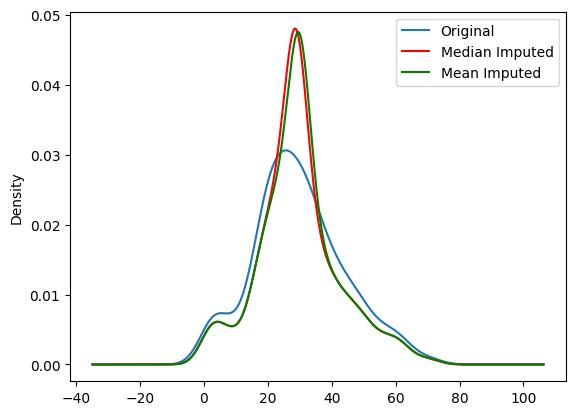

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Variable Distribution
x_train['Age'].plot(kind='kde', ax=ax, label='Original')

# Variable imputed with median
x_train['Age_median'].plot(kind='kde', ax=ax, color='red', label='Median Imputed')

# Variable imputed with mean
x_train['Age_mean'].plot(kind='kde', ax=ax, color='green', label='Mean Imputed')

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

### Change in Distribution in Fare

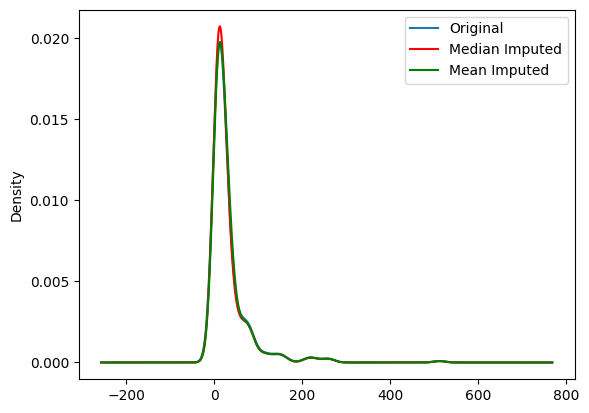

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Variable Distribution
x_train['Fare'].plot(kind='kde', ax=ax, label='Original')

# Variable imputed with median
x_train['Fare_median'].plot(kind='kde', ax=ax, color='red', label='Median Imputed')

# Variable imputed with mean
x_train['Fare_mean'].plot(kind='kde', ax=ax, color='green', label='Mean Imputed')

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

### Check Covariance

In [17]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


### Check Correlation

In [18]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


### Box Plot for Age

<Axes: >

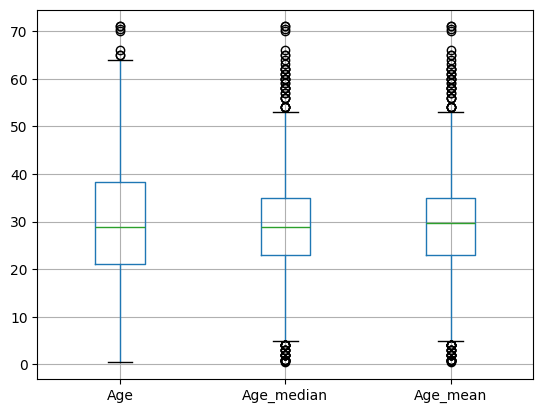

In [19]:
x_train[['Age', 'Age_median', 'Age_mean']].boxplot()

### Box Plot for Fare

<Axes: >

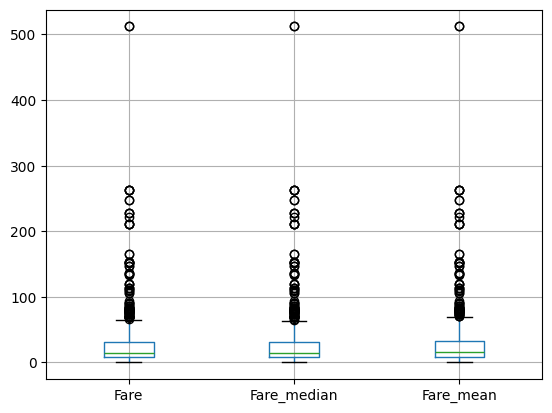

In [20]:
x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()